In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd


In [34]:

def fit_and_plot_vols_for_underlying_df(df, und):
    log_rets = np.log(df / df.shift(1)).dropna()
    stds = log_rets.std() * np.sqrt(365)

    log_rets = (df - df.shift(1)).dropna()
    stds = log_rets.std() * np.sqrt(365)


    mu0 = 0.4
    sigma0 = 0.3
    alpha0 = 1.0

    def error_func(params):
        p_mu, p_sigma, p_alpha = params
        _modelled_vols = np.array([(p_mu + p_sigma*(np.exp(-p_alpha*(15+30*i)/365))) for i in range(len(stds))])
        value_error = sum((_modelled_vols - stds.values)**2)
        return value_error

    initial_guess = [mu0, sigma0, alpha0]
    bounds = [(0, 10.0), (0, 10.0), (0.5, 2.0)]
    result = minimize(error_func, initial_guess, bounds=bounds)

    mu, sigma, alpha = result.x
    modelled_vols = np.array([(mu + sigma*(np.exp(-alpha*(15+30*i)/365))) for i in range(len(stds))])

    dates = stds.index
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dates, stds, color="navy", label="Realised Vols")
    ax.plot(dates, modelled_vols, color="green", label=f"Modelled Vols (mu, sigma, alpha)=({mu:.4f},{sigma:.4f},{alpha:.4f})")
    # ax.fill_between(dates, CIdown_stds, CIup_stds, color="skyblue", alpha=0.3, label="95% CI")
    ax.set_title(f"{und} vols")
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    ax.grid(True)

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.hist(log_rets["M2"])

    fig3, ax3 = plt.subplots(figsize=(10, 5))
    ax3.plot(df)


    return mu, sigma, alpha

xl_file_path = "C:\\Users\\marti.fernandezreal\\OneDrive - BAYEGAN DIS TIC. A.S\\Marti\\BloombergData\\bbg_data_extractor.xlsx"

def read_df_from_xl_database(und):
    df = pd.read_excel(
            xl_file_path,
            sheet_name=und+"_bymonth",
            usecols="A:Y",
            skiprows=1,
            index_col=0)
    df.index.name = None
    return df

Modelled Vols JKM_TFU: (mu, sigma, alpha)=(2.2906,0.0000,0.5000)


C:\Marti\python_tests_2\env_local\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
C:\Marti\python_tests_2\env_local\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
C:\Marti\python_tests_2\env_local\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Marti\python_tests_2\env_local\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


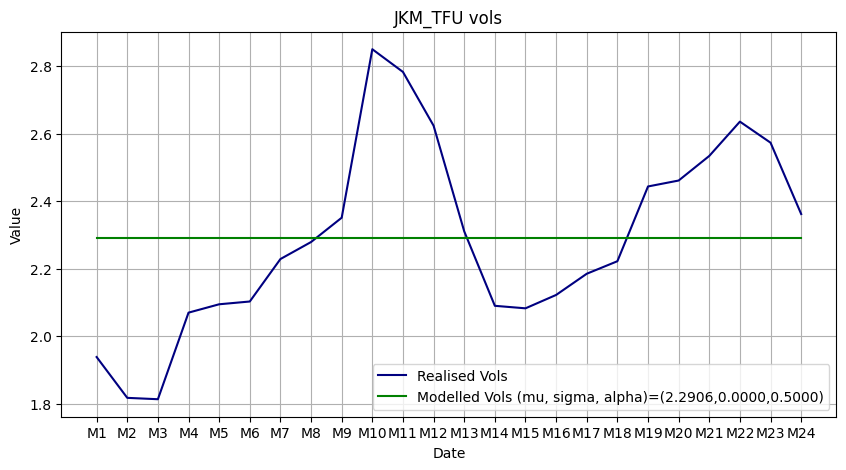

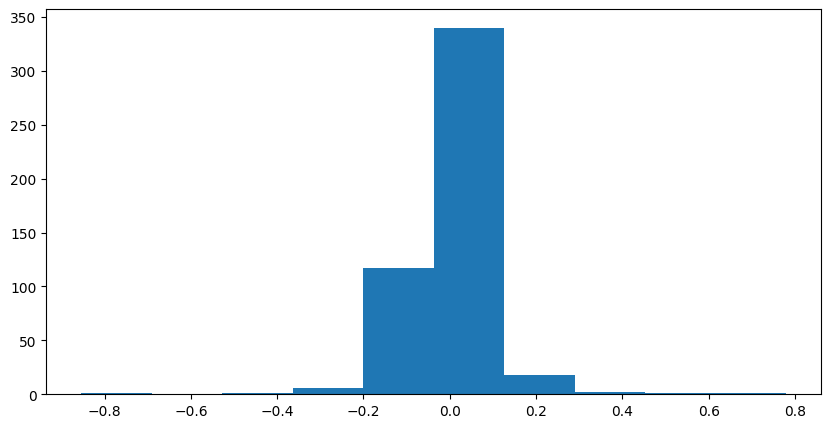

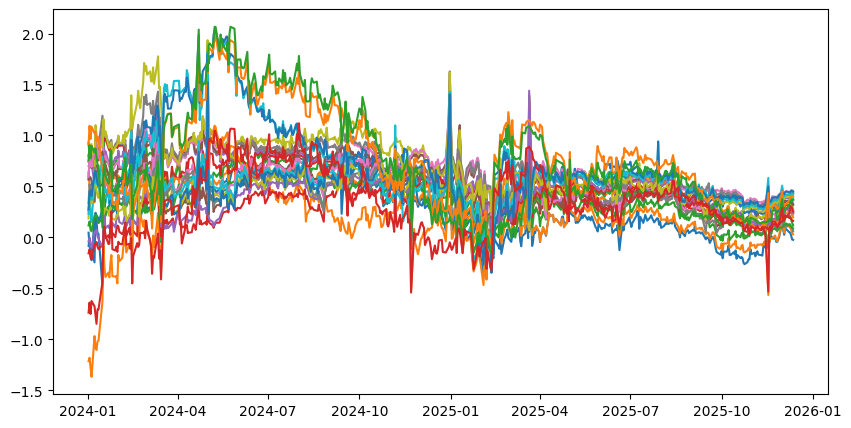

In [35]:
dict_result_vols = {}
und_to_fit = ["HH", "TFU_HH", "JKM_HH", "JKM_TFU"]
und_to_fit = ["JKM_TFU"]

for und in und_to_fit:
    if und.split("_")[0] == und:  # Single underlying, go ahead
        df = read_df_from_xl_database(und)
    else:
        und1, und2 = und.split("_")
        df1 = read_df_from_xl_database(und1)
        df2 = read_df_from_xl_database(und2)
        common_idx = df1.index.intersection(df2.index)
        common_cols = df1.columns.intersection(df2.columns)

        df = df1.loc[common_idx, common_cols] - df2.loc[common_idx, common_cols]

    _results = fit_and_plot_vols_for_underlying_df(df, und)
    dict_result_vols[und] = _results
    print(f"Modelled Vols {und}: (mu, sigma, alpha)=({_results[0]:.4f},{_results[1]:.4f},{_results[2]:.4f})")


C:\Users\marti.fernandezreal\AppData\Local\Temp\ipykernel_52828\2801810659.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, ax2 = plt.subplots(figsize=(4, 2))


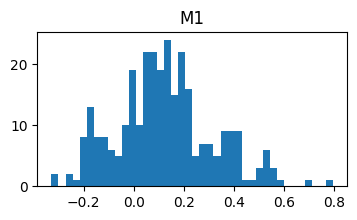

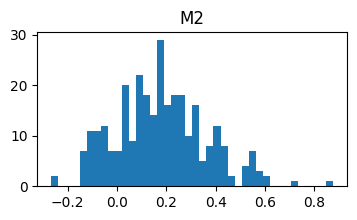

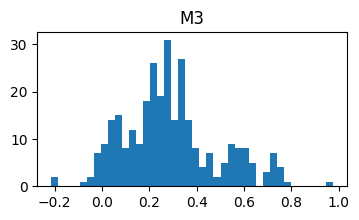

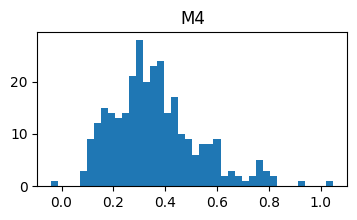

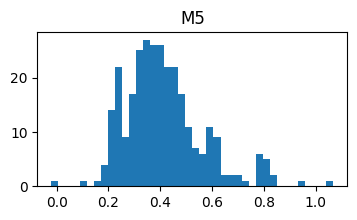

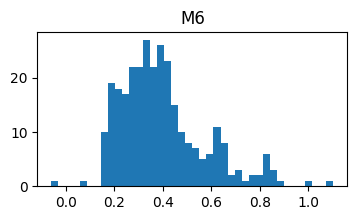

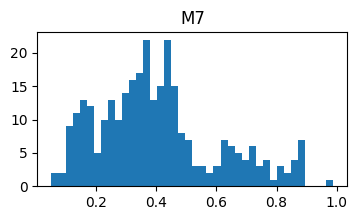

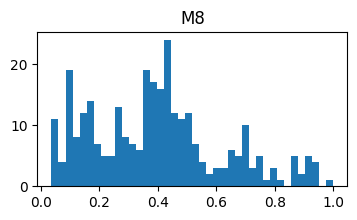

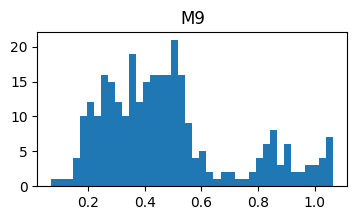

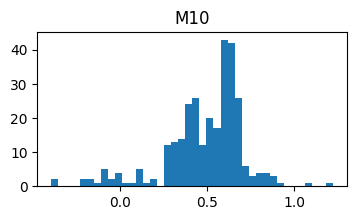

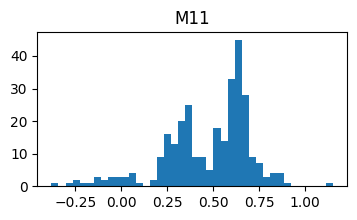

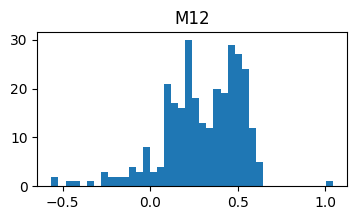

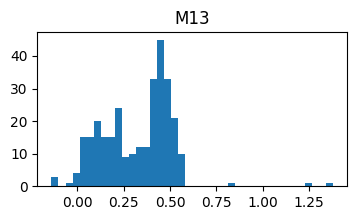

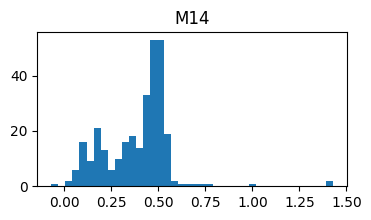

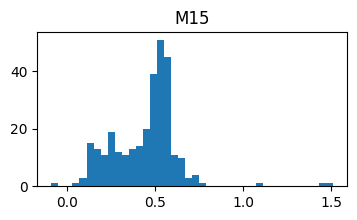

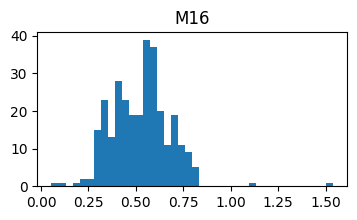

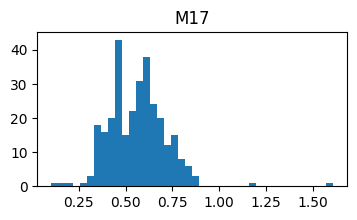

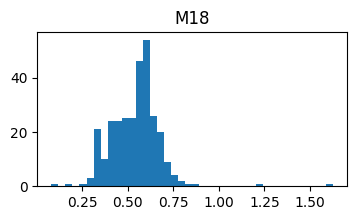

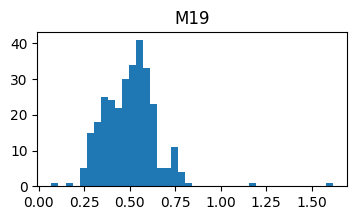

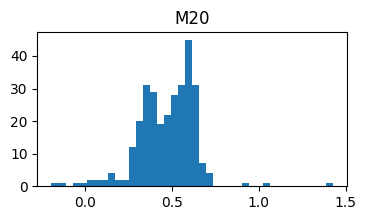

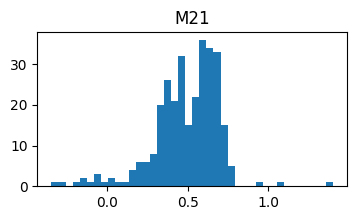

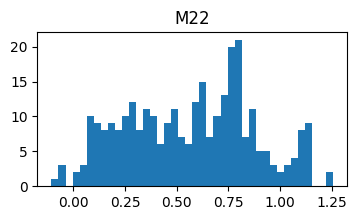

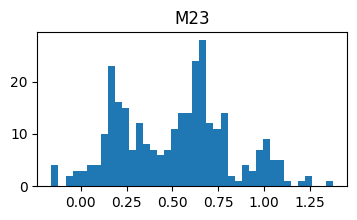

In [36]:
short_df = df[-300:]

# fig2, ax2 = plt.subplots(figsize=(4, 2))
month = "M1"
for month in ["M"+str(i) for i in range(1, 24)]:
    fig2, ax2 = plt.subplots(figsize=(4, 2))
    ax2.hist(short_df[month], bins=40)
    ax2.set_title(month);